# Ethical Intent in QAC — Results

Data: `ethical_data_final_5pct.csv`, `ethical_logical_5pct.csv`, `ethics_classified_5pct.csv`

In [21]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 10,
})

DIR = os.path.dirname(os.path.abspath("ethics_results.ipynb"))
FIG_DIR = os.path.join(DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

In [22]:
# Short labels for legends and tables
CATEGORIES = {
    "environmental_sustainability":  "Environmental Sustainability",
    "fair_trade_labor_human_rights": "Fair Trade / Labour",
    "animal_welfare":                "Animal Welfare",
    "privacy_data_ethics":           "Privacy & Data Ethics",
    "accessibility_inclusion":       "Accessibility & Inclusion",
}

# Multi-line labels for axis ticks
CATEGORIES_DISPLAY = {
    "environmental_sustainability":  "Environmental\nSustainability",
    "fair_trade_labor_human_rights": "Fair Trade /\nLabour",
    "animal_welfare":                "Animal\nWelfare",
    "privacy_data_ethics":           "Privacy &\nData Ethics",
    "accessibility_inclusion":       "Accessibility\n& Inclusion",
}

DOMAIN_ORDER = [
    "Books", "Business, Industry\nand Science", "Car and\nMotorbike",
    "Clothes, Shoes\nand Watches", "Electronics\nand Computers",
    "Films, TV, Music\nand Games", "Food and\nGrocery",
    "Health and\nBeauty", "Home, Garden\nand DIY",
    "None of\nthe above", "Sports and\nOutdoors",
    "Stationery &\nOffice Supplies", "Toys, Children\nand Baby",
]

DOMAIN_MAP = {
    "Books":                          "Books",
    "Business Industry and Science":  "Business, Industry\nand Science",
    "Car and Motorbike":              "Car and\nMotorbike",
    "Clothes Shoes and Watches":      "Clothes, Shoes\nand Watches",
    "Electronics and Computers":      "Electronics\nand Computers",
    "Films TV Music and Games":       "Films, TV, Music\nand Games",
    "Food and Grocery":               "Food and\nGrocery",
    "Health and Beauty":              "Health and\nBeauty",
    "Home Garden and DIY":            "Home, Garden\nand DIY",
    "None of the above":              "None of\nthe above",
    "Sports and Outdoors":            "Sports and\nOutdoors",
    "Stationery and Office Supplies": "Stationery &\nOffice Supplies",
    "Toys Children and Baby":         "Toys, Children\nand Baby",
}

COLORS_CAT = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
COLORS_RDA = {"Retained": "#1f77b4", "Dropped": "#ff7f0e", "Added": "#2ca02c"}

def word_count(s):
    if pd.isna(s):
        return 0
    return len(str(s).split())

In [23]:
DATA_DIR = os.path.join(DIR, os.pardir)  # CSVs live one level up

tok = pd.read_csv(os.path.join(DATA_DIR, "ethical_data_final_5pct.csv"))
lg  = pd.read_csv(os.path.join(DATA_DIR, "ethical_logical_5pct.csv"))
cl  = pd.read_csv(os.path.join(DATA_DIR, "ethics_classified_5pct.csv"),
                   usecols=["query_id", "product_domain"])

# Merge domain labels into both datasets
lg = lg.merge(cl, on="query_id", how="left")
lg["product_domain"] = lg["product_domain"].fillna("Unclassified")
lg["domain_display"] = lg["product_domain"].map(DOMAIN_MAP).fillna(lg["product_domain"])

tok = tok.merge(cl, on="query_id", how="left")
tok["product_domain"] = tok["product_domain"].fillna("Unclassified")

# Word counts for transition logic
lg["prefix_wc"] = lg["prefixes"].apply(word_count)
lg["query_wc"]  = lg["final_search_term"].apply(word_count)

print(f"Token-level: {len(tok):,} rows")
print(f"Query-level: {len(lg):,} rows")
print(f"Domains:     {lg['product_domain'].nunique()}")
lg.head(3)

Token-level: 136,500 rows
Query-level: 135,297 rows
Domains:     14


,query_id,session_id,prefixes,first_prefix_typed_time,final_search_term,search_time,popularity,environmental_sustainability_prefix,environmental_sustainability_final,fair_trade_labor_human_rights_prefix,...,animal_welfare_prefix,animal_welfare_final,privacy_data_ethics_prefix,privacy_data_ethics_final,accessibility_inclusion_prefix,accessibility_inclusion_final,product_domain,domain_display,prefix_wc,query_wc
0,3865470717289,EQruX7ZKaZRZcyAW/VE74B8mxGVmeRScOR13mz6ec6M=,teepee tea,2023-09-02 01:21:17.752,teepee tea thai herbal natural organic pain,2023-09-02 01:21:30,102,False,True,False,...,False,False,False,False,False,False,Food and Grocery,Food and\nGrocery,2,7
1,3865470888009,9M20gwoyhwor1VrfQ77G9H1l9VKipthz1S1JGLWxLIU=,samsung fold 4 pr,2023-09-26 14:26:46.811,samsung fold 4 privacy screen protector,2023-09-26 14:26:53,7,False,False,False,...,False,False,False,True,False,False,Electronics and Computers,Electronics\nand Computers,4,6
2,3865470681149,QHULyI0FJP9OQqqKzdWq7mWVnTeVbd9jHoIkLWD1Zss=,ethically,2023-09-30 03:13:54.07,ethically sourced palo santo,2023-09-30 03:14:04,6,False,False,False,...,False,False,False,False,False,False,Health and Beauty,Health and\nBeauty,1,4


In [24]:
# Summary statistics
total = len(lg)
any_final = pd.Series(False, index=lg.index)
for cat in CATEGORIES:
    any_final |= lg[f"{cat}_final"].astype(bool)

print(f"Total ethical queries: {total:,}")
print(f"Keyword in final:     {any_final.sum():,} ({any_final.mean()*100:.1f}%)")

print(f"\n{'Category':<35s} {'N':>8s} {'Mean len':>10s} {'Med pop':>10s}")
print("-" * 65)
for cat, label in CATEGORIES.items():
    mask = lg[f"{cat}_final"].astype(bool)
    if not mask.any():
        continue
    print(f"{label:<35s} {mask.sum():>8,} {lg.loc[mask,'query_wc'].mean():>10.2f} {lg.loc[mask,'popularity'].median():>10.0f}")

Total ethical queries: 135,297
Keyword in final:     135,297 (100.0%)

Category                                   N   Mean len    Med pop
-----------------------------------------------------------------
Environmental Sustainability         105,984       3.81         43
Fair Trade / Labour                    1,397       3.55          6
Animal Welfare                         9,573       3.40         24
Privacy & Data Ethics                 11,597       5.00         44
Accessibility & Inclusion              7,546       4.15         22


## Table 2 — QAC Interaction Conditions

In [25]:
# QAC interaction conditions per category
rows = []
for cat, label in CATEGORIES.items():
    p = lg[f"{cat}_prefix"].astype(bool)
    f = lg[f"{cat}_final"].astype(bool)
    tt = (p & f).sum()
    tf = (p & ~f).sum()
    ft = (~p & f).sum()
    total = tt + tf + ft
    if total == 0:
        continue
    rows.append({
        "Category": label,
        "Retained": f"{tt/total*100:.1f}% ({tt:,})",
        "Dropped":  f"{tf/total*100:.1f}% ({tf:,})",
        "Added":    f"{ft/total*100:.1f}% ({ft:,})",
        "N": f"{total:,}",
    })

pd.DataFrame(rows).set_index("Category")

,Retained,Dropped,Added,N
Category,,,,
Environmental Sustainability,"55.4% (58,664)",0.0% (0),"44.6% (47,320)","105,984"
Fair Trade / Labour,"74.8% (1,045)",0.0% (0),25.2% (352),"1,397"
Animal Welfare,"74.4% (7,124)",0.0% (0),"25.6% (2,449)","9,573"
Privacy & Data Ethics,"51.6% (5,982)",0.0% (0),"48.4% (5,615)","11,597"
Accessibility & Inclusion,"55.9% (4,217)",0.0% (0),"44.1% (3,329)","7,546"


## Figure 2 — Ethical Intent by Product Domain

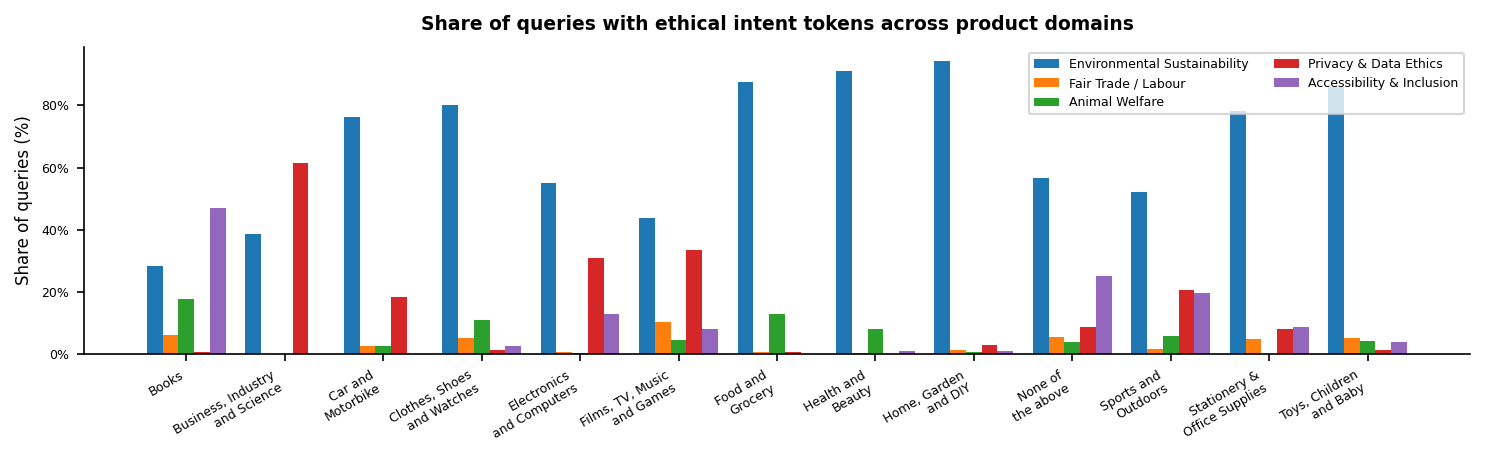

In [26]:
domain_totals = lg.groupby("domain_display").size()

data = {}
for cat, label in CATEGORIES_DISPLAY.items():
    counts = lg[lg[f"{cat}_final"].astype(bool)].groupby("domain_display").size()
    data[label] = (counts / domain_totals * 100).fillna(0)

matrix = pd.DataFrame(data)
matrix = matrix.reindex([d for d in DOMAIN_ORDER if d in matrix.index])

n_dom = len(matrix)
n_cat = len(CATEGORIES)
x = np.arange(n_dom)
w = 0.8 / n_cat

# Wider and shorter — extra width gives x-labels room without needing height
fig, ax = plt.subplots(figsize=(10, 3.2))
for i, (col, color) in enumerate(zip(matrix.columns, COLORS_CAT)):
    vals = matrix[col].values
    bars = ax.bar(x + i * w - 0.4 + w / 2, vals, w,
                   label=col.replace("\n", " "), color=color)

ax.set_xticks(x)
ax.set_xticklabels(matrix.index, fontsize=6, rotation=30, ha="right")
ax.set_ylabel("Share of queries (%)", fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc="upper right", fontsize=6, ncol=2)
ax.set_title("Share of queries with ethical intent tokens across product domains",
             fontsize=9, fontweight="bold", pad=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='both', labelsize=6)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "figure2_domain_shares.pdf"))
fig.savefig(os.path.join(FIG_DIR, "figure2_domain_shares.png"))
plt.show()

## Table 3 — Retention and Addition Rates by Query Length

In [27]:
# Retention & Addition rates by query length
length_bins = [(2, 2, "2"), (3, 3, "3"), (4, 4, "4"), (5, 5, "5"), (6, 99, "6+")]

rows_ret, rows_add = [], []
for cat, label in CATEGORIES.items():
    p_col = lg[f"{cat}_prefix"].astype(bool)
    f_col = lg[f"{cat}_final"].astype(bool)
    retained = p_col & f_col
    added    = ~p_col & f_col
    relevant = p_col | f_col

    ret_row = {"Category": label}
    add_row = {"Category": label}
    for wc_lo, wc_hi, lbl in length_bins:
        wc_mask = lg["query_wc"].between(wc_lo, wc_hi)
        n_rel = (wc_mask & relevant).sum()
        n_ret = (wc_mask & retained).sum()
        n_add = (wc_mask & added).sum()
        ret_row[lbl] = f"{n_ret/n_rel*100:.1f}%" if n_rel >= 10 else "—"
        add_row[lbl] = f"{n_add/n_rel*100:.1f}%" if n_rel >= 10 else "—"
    rows_ret.append(ret_row)
    rows_add.append(add_row)

print("Retention rate by query length")
print(pd.DataFrame(rows_ret).set_index("Category").to_string())
print("\nAddition rate by query length")
print(pd.DataFrame(rows_add).set_index("Category").to_string())

Retention rate by query length
                                  2      3      4      5     6+
Category                                                       
Environmental Sustainability  68.9%  61.3%  50.8%  50.6%  37.0%
Fair Trade / Labour           83.6%  82.5%  74.6%  63.7%  46.9%
Animal Welfare                92.4%  79.8%  67.6%  57.1%  34.8%
Privacy & Data Ethics         83.2%  59.7%  59.2%  53.1%  38.4%
Accessibility & Inclusion     69.4%  65.9%  50.7%  49.8%  44.3%

Addition rate by query length
                                  2      3      4      5     6+
Category                                                       
Environmental Sustainability  31.1%  38.7%  49.2%  49.4%  63.0%
Fair Trade / Labour           16.4%  17.5%  25.4%  36.2%  53.1%
Animal Welfare                 7.6%  20.2%  32.4%  42.9%  65.2%
Privacy & Data Ethics         16.8%  40.3%  40.8%  46.9%  61.6%
Accessibility & Inclusion     30.6%  34.1%  49.3%  50.2%  55.7%


## Figure 4 — Per-Token Transition Breakdown

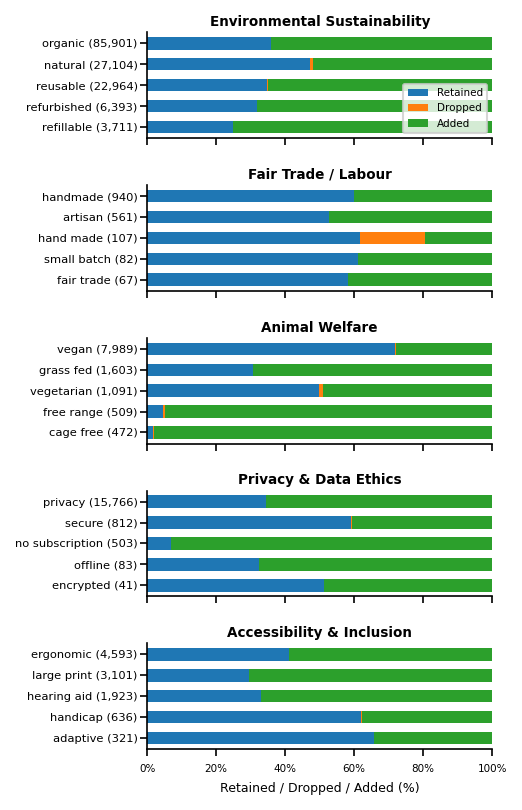

In [28]:
cats = list(CATEGORIES.keys())
n_panels = len(cats)

# 0.5\textwidth of full page = 3.58in; 5 tokens per panel keeps it compact
fig, axes = plt.subplots(n_panels, 1, figsize=(3.58, 5.5), sharey=False)

for ax, cat in zip(axes, cats):
    pcol, fcol = f"{cat}_prefix", f"{cat}_final"

    all_tokens = pd.concat([tok[pcol].dropna(), tok[fcol].dropna()]).unique()
    token_rows = []
    for token in all_tokens:
        has_p = tok[pcol] == token
        has_f = tok[fcol] == token
        retained = (has_p & has_f).sum()
        dropped  = (has_p & (tok[fcol] != token)).sum() + (has_p & tok[fcol].isna()).sum()
        added    = (has_f & (tok[pcol] != token)).sum() + (has_f & tok[pcol].isna()).sum()
        total_t  = retained + dropped + added
        if total_t == 0:
            continue
        token_rows.append({"token": token, "n": total_t,
                           "Retained": retained, "Dropped": dropped, "Added": added})

    if not token_rows:
        ax.set_visible(False)
        continue

    tdf = pd.DataFrame(token_rows).sort_values("n", ascending=True).tail(5)
    y = np.arange(len(tdf))
    totals = tdf["n"].values.astype(float)

    ret_pct  = tdf["Retained"].values / totals * 100
    drop_pct = tdf["Dropped"].values  / totals * 100
    add_pct  = tdf["Added"].values    / totals * 100

    ax.barh(y, ret_pct, height=0.6, color=COLORS_RDA["Retained"], label="Retained")
    ax.barh(y, drop_pct, height=0.6, left=ret_pct, color=COLORS_RDA["Dropped"], label="Dropped")
    ax.barh(y, add_pct, height=0.6, left=ret_pct + drop_pct,
            color=COLORS_RDA["Added"], label="Added")

    ax.set_yticks(y)
    ax.set_yticklabels([f"{t} ({n:,})" for t, n in zip(tdf["token"], tdf["n"])],
                       fontsize=5.5)
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis='x', labelsize=5)
    ax.tick_params(axis='y', pad=1)
    ax.set_title(CATEGORIES[cat], fontsize=6.5, fontweight="bold", pad=3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Only show x-label on bottom panel
    if ax is axes[-1]:
        ax.set_xlabel("Retained / Dropped / Added (%)", fontsize=6)
    else:
        ax.set_xticklabels([])

    if ax is axes[0]:
        ax.legend(loc="lower right", fontsize=5, framealpha=0.8)

plt.subplots_adjust(hspace=0.55)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "figure4_token_transitions.pdf"))
fig.savefig(os.path.join(FIG_DIR, "figure4_token_transitions.png"))
plt.show()